In [18]:
#Importing required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


# Cleaning the health data


In [2]:
#Installing openpyxl to open excel file
!pip install openpyxl

In [3]:
#Load the data
health_data=pd.read_csv("../Group1-Healthcare_Access_Inequality_Predictor/Data/health_data.csv")

In [4]:
#Displaying the number of rows and columns that are in the data
health_data.shape

(7257, 28)

In [6]:
#Displaying the first row
health_data.head(1)

,Unnamed: 0,facility_type_name,owner_name,owner_type_name,admission_status_name,county,constituency,ward_name,average_rating,facility_services,...,number_of_hdu_beds,number_of_inpatient_beds,number_of_maternity_beds,number_of_isolation_beds,number_of_general_theatres,number_of_maternity_theatres,number_of_minor_theatres,number_of_eye_theatres,new_born_unit,facility_catchment_population
0,2,Dispensary,Ministry of Health,Ministry of Health,Admitting Maternity Patients Only,Trans Nzoia,Endebess,Endebess,0.0,[],...,0,0,2,0,0,0,0,0,False,5000.0


In [7]:
#Dropping the columns that are not needed
health_data_clean=health_data.drop(columns=["new_born_unit","admission_status_name","owner_type_name",
                                            "number_of_hdu_beds","number_of_isolation_beds","number_of_general_theatres",
                                            "number_of_maternity_theatres","number_of_minor_theatres","number_of_eye_theatres",
                                            "admission_status_name",
                                            "sub_county_name","number_of_icu_beds","number_of_emergency_casualty_beds","facility_services","facility_infrastructure"],axis=1)	

In [8]:
#Displaying the number of rows and columns that are in the data
health_data_clean.shape

(7257, 14)

In [9]:
#Checking the number of missing enteries per column
health_data_clean.isnull().sum()

Unnamed: 0                          0
facility_type_name                  0
owner_name                          0
county                              0
constituency                        0
ward_name                           0
average_rating                      0
keph_level_name                     0
lat_long                          160
number_of_beds                      0
number_of_cots                      0
number_of_inpatient_beds            0
number_of_maternity_beds            0
facility_catchment_population    4180
dtype: int64

In [11]:
#Saving the data to csv file
health_data_clean.to_csv("../Group1-Healthcare_Access_Inequality_Predictor/Data/health_data_clean.csv")

In [12]:
#Reseting the index of the cleaned data
health_data_clean.reset_index(inplace=True)
health_data_clean

,index,Unnamed: 0,facility_type_name,owner_name,county,constituency,ward_name,average_rating,keph_level_name,lat_long,number_of_beds,number_of_cots,number_of_inpatient_beds,number_of_maternity_beds,facility_catchment_population
0,0,2,Dispensary,Ministry of Health,Trans Nzoia,Endebess,Endebess,0.0,Level 2,"[1.02393, 34.77484]",2,0,0,2,5000.0
1,1,3,Dispensary,Ministry of Health,Trans Nzoia,Endebess,Chepchoina,0.0,Level 2,"[1.1351849999999999, 34.806785]",0,0,0,0,6000.0
2,2,4,Dispensary,Ministry of Health,Trans Nzoia,Endebess,Matumbei,0.0,Level 2,"[1.08089, 34.80747]",3,0,0,3,10426.0
3,3,5,Dispensary,Ministry of Health,Trans Nzoia,Endebess,Endebess,0.0,Level 2,"[1.037451, 34.861203]",3,0,0,3,4579.0
4,4,6,Dispensary,Ministry of Health,Trans Nzoia,Endebess,Chepchoina,0.0,Level 2,"[1.2035879999999999, 34.803397]",3,0,0,3,6459.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7252,7252,16105,Primary care hospitals,Ministry of Health,Taita Taveta,Voi,Mbololo,0.0,Level 4,"[-3.38928, 38.56007]",112,0,0,0,NaN
7253,7253,16106,Primary care hospitals,Ministry of Health,Nandi,Nandi Hills,Nandi Hills,0.0,Level 4,"[0.10404000000000001, 35.18361]",89,5,0,0,NaN
7254,7254,16107,Primary care hospitals,Ministry of Health,Vihiga,Hamisi,Gisambai,0.0,Level 4,"[0.07351, 34.80206]",16,4,0,0,NaN
7255,7255,16108,Primary care hospitals,Ministry of Health,Nandi,Tinderet,Tinderet,0.0,Level 4,"[0.00568, 35.30777]",28,5,0,0,NaN


In [14]:
#Dropping more coulmuns from the dataframe
health_data_clean.drop(columns=["index","Unnamed: 0"],inplace=True)

In [15]:
#Displaying the first five rows of the daraframe
health_data_clean.head()

,facility_type_name,owner_name,county,constituency,ward_name,average_rating,keph_level_name,lat_long,number_of_beds,number_of_cots,number_of_inpatient_beds,number_of_maternity_beds,facility_catchment_population
0,Dispensary,Ministry of Health,Trans Nzoia,Endebess,Endebess,0.0,Level 2,"[1.02393, 34.77484]",2,0,0,2,5000.0
1,Dispensary,Ministry of Health,Trans Nzoia,Endebess,Chepchoina,0.0,Level 2,"[1.1351849999999999, 34.806785]",0,0,0,0,6000.0
2,Dispensary,Ministry of Health,Trans Nzoia,Endebess,Matumbei,0.0,Level 2,"[1.08089, 34.80747]",3,0,0,3,10426.0
3,Dispensary,Ministry of Health,Trans Nzoia,Endebess,Endebess,0.0,Level 2,"[1.037451, 34.861203]",3,0,0,3,4579.0
4,Dispensary,Ministry of Health,Trans Nzoia,Endebess,Chepchoina,0.0,Level 2,"[1.2035879999999999, 34.803397]",3,0,0,3,6459.0


In [16]:
#Displaying the number of rows and columns that are in the data after dropping some columns
health_data_clean.shape

(7257, 13)

In [19]:
#Calculating the mean of the facility catchment population
mean_fcp = health_data_clean["facility_catchment_population"].median()
mean_fcp

np.float64(3220.0)

In [20]:
#Dropping the missing values of the facility catchment population
health_data_clean.dropna(inplace=True)

In [21]:
#Displaying the number of rows and columns that are in the data after dropping the missing rows of facility catchment population
health_data_clean.shape

(3053, 13)

In [22]:
#Checking the number of missing enteries per column
health_data_clean.isnull().sum()

facility_type_name               0
owner_name                       0
county                           0
constituency                     0
ward_name                        0
average_rating                   0
keph_level_name                  0
lat_long                         0
number_of_beds                   0
number_of_cots                   0
number_of_inpatient_beds         0
number_of_maternity_beds         0
facility_catchment_population    0
dtype: int64

In [23]:
#Getting info of the statistical numerical values 
health_data_clean.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
facility_type_name,3053,21,Dispensary,2064,NaN,NaN,NaN,NaN,NaN,NaN,NaN
owner_name,3053,7,Ministry of Health,2894,NaN,NaN,NaN,NaN,NaN,NaN,NaN
county,3053,47,Makueni,192,NaN,NaN,NaN,NaN,NaN,NaN,NaN
constituency,3053,284,Makueni,63,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ward_name,3053,1072,Township,22,NaN,NaN,NaN,NaN,NaN,NaN,NaN
average_rating,3053.0,NaN,NaN,NaN,0.0273,0.276839,0.0,0.0,0.0,0.0,5.0
keph_level_name,3053,5,Level 2,2195,NaN,NaN,NaN,NaN,NaN,NaN,NaN
lat_long,3053,3036,"[0.052869, 34.896204]",2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
number_of_beds,3053.0,NaN,NaN,NaN,5.802489,27.605629,0.0,0.0,0.0,2.0,650.0
number_of_cots,3053.0,NaN,NaN,NaN,0.624304,2.795456,0.0,0.0,0.0,0.0,58.0


In [24]:
# Calculating the sum of all entities in the dataframe and grouping them per county
health_data_aggregate = health_data_clean.groupby('county').agg({
    'average_rating':'mean',
    'number_of_beds':'sum',
    'number_of_cots':'sum',
    'number_of_inpatient_beds':'sum',
    'number_of_maternity_beds':'sum',
    'facility_catchment_population':'sum',
    'facility_type_name':'count'
}).reset_index()

In [25]:
#Displaying the first five rows of the data frame
health_data_aggregate.head()

,county,average_rating,number_of_beds,number_of_cots,number_of_inpatient_beds,number_of_maternity_beds,facility_catchment_population,facility_type_name
0,Baringo,0.003902,284,16,15,19,204309.0,41
1,Bomet,0.012987,157,19,12,71,398032.0,77
2,Bungoma,0.019748,881,67,295,210,1342280.0,129
3,Busia,0.012500,523,1,219,83,243454.0,35
4,Elgeyo Marakwet,0.050000,237,23,2,67,108943.0,25


In [26]:
#Getting info of the statistical numerical values 
health_data_aggregate.describe().T

,count,mean,std,min,25%,50%,75%,max
average_rating,47.0,0.032395,4.734431e-02,0.0,0.002393,0.0129,0.034523,1.842105e-01
number_of_beds,47.0,376.914894,3.031966e+02,0.0,136.500000,295.0000,571.000000,1.058000e+03
number_of_cots,47.0,40.553191,3.450949e+01,0.0,17.000000,33.0000,62.000000,1.760000e+02
number_of_inpatient_beds,47.0,243.255319,7.845373e+02,0.0,3.500000,39.0000,154.500000,5.298000e+03
number_of_maternity_beds,47.0,107.702128,9.053823e+01,0.0,33.000000,83.0000,182.000000,3.710000e+02
facility_catchment_population,47.0,675410.723404,1.309159e+06,45055.0,225977.000000,375997.0000,671880.500000,9.024658e+06
facility_type_name,47.0,64.957447,4.089114e+01,12.0,32.500000,54.0000,91.000000,1.920000e+02


In [27]:
#Remaning the facity name to the number of the facilities in the county(public and NGOs facilities)
health_data_aggregate.rename(columns={'facility_type_name':'no._of_facilities'},inplace= True)

In [28]:
#Displaying the first fuve rows in the dataframe
health_data_aggregate.head()

,county,average_rating,number_of_beds,number_of_cots,number_of_inpatient_beds,number_of_maternity_beds,facility_catchment_population,no._of_facilities
0,Baringo,0.003902,284,16,15,19,204309.0,41
1,Bomet,0.012987,157,19,12,71,398032.0,77
2,Bungoma,0.019748,881,67,295,210,1342280.0,129
3,Busia,0.012500,523,1,219,83,243454.0,35
4,Elgeyo Marakwet,0.050000,237,23,2,67,108943.0,25


# Cleaning the population 2019 census data

In [29]:
#Loading the pop. census data
census_data = pd.read_excel("../Group1-Healthcare_Access_Inequality_Predictor/Data/Kenya_2019_census.xlsx")

In [30]:
#Displaying the first fuve rows in the census data
census_data.head()

,County,Pop_total,Male,Female,H.H_total,HH_Conventional,HH_Group quarters,Persons per Sq. Km,Unnamed: 8,Unnamed: 9
0,MOMBASA,1208333,610257,598046,378422,376295,2127,5495.008378,NaN,NaN
1,KWALE,866820,425121,441681,173176,172802,374,105.022558,NaN,NaN
2,KILIFI,1453787,704089,749673,298472,297990,482,115.809472,NaN,NaN
3,TANA RIVER,315943,158550,157391,68242,66984,1258,8.335430,NaN,NaN
4,LAMU,143920,76103,67813,37963,34231,3732,22.906165,NaN,0.0


In [64]:
#Changing the font of the county names from uppercase to a normal sentence case
#census_data['County'] = census_data['County'].str.title()

In [59]:
#Dropping the unwanted columns in the census data
census_data.drop(columns=["male","female","h.h_total","hh_conventional","hh_group quarters"],inplace=True)
census_data.drop(columns=["persons per sq. km"],inplace=True)

In [60]:
#Displaying the first fuve rows in the census data after dropping other columns
census_data.head()

,county,pop_total
0,Mombasa,1208333
1,Kwale,866820
2,Kilifi,1453787
3,Tana River,315943
4,Lamu,143920


In [65]:
#Displaying the first fuve rows in the census data after case changing
census_data.head()

,county,pop_total
0,Mombasa,1208333
1,Kwale,866820
2,Kilifi,1453787
3,Tana River,315943
4,Lamu,143920


In [35]:
#Changing the column names from sentence case to lower case to match the health data
#census_data.columns= census_data.columns.str.lower()

In [69]:
#Sorting the counties in alphabetical order to match the health data 
census_data_sorted = census_data.sort_values(by='county')
#Displaying the first five rows in the dataframe after sorting
census_data_sorted.head()

,county,pop_total
29,Baringo,666763
35,Bomet,875689
38,Bungoma,1670570
39,Busia,893681
27,Elgeyo/Marakwet,454480


In [70]:
#Resseting the 9ndex after sorting the counties 
census_data_sorted.reset_index(inplace=True)
census_data_sorted.head()

,index,county,pop_total
0,29,Baringo,666763
1,35,Bomet,875689
2,38,Bungoma,1670570
3,39,Busia,893681
4,27,Elgeyo/Marakwet,454480


In [71]:
#Dropping the index column
census_data_sorted.drop(columns=["index"],inplace=True)
census_data_sorted.head()

,county,pop_total
0,Baringo,666763
1,Bomet,875689
2,Bungoma,1670570
3,Busia,893681
4,Elgeyo/Marakwet,454480


In [40]:
#Displaying the first fuve rows in the census data after dropping the index column
census_data_sorted.head()

,county,pop_total,male,female,h.h_total,hh_conventional,hh_group quarters,persons per sq. km
0,Baringo,666763,336322,330428,142518,141877,641,60.699676
1,Bomet,875689,434287,441379,187641,187230,411,349.286947
2,Bungoma,1670570,812146,858389,358796,357714,1082,552.448500
3,Busia,893681,426252,467401,198152,197944,208,525.761629
4,Elgeyo/Marakwet,454480,227317,227151,99861,99119,742,149.891529


In [77]:
#Linking(concatenating) the cleaned health data together with the census data
Pop_health_data = pd.concat([census_data_sorted,health_data_aggregate],axis=1)
#Displaying the first fuve rows in the census data after concatenation
Pop_health_data.head()

,county,pop_total,county,average_rating,number_of_beds,number_of_cots,number_of_inpatient_beds,number_of_maternity_beds,facility_catchment_population,no._of_facilities
0,Baringo,666763,Baringo,0.003902,284,16,15,19,204309.0,41
1,Bomet,875689,Bomet,0.012987,157,19,12,71,398032.0,77
2,Bungoma,1670570,Bungoma,0.019748,881,67,295,210,1342280.0,129
3,Busia,893681,Busia,0.012500,523,1,219,83,243454.0,35
4,Elgeyo/Marakwet,454480,Elgeyo Marakwet,0.050000,237,23,2,67,108943.0,25


In [78]:
#Deleting the duplicated county names in the final data after concatenation
Pop_health_data = Pop_health_data.loc[:, ~Pop_health_data.columns.duplicated()]
#Displaying the first five rows
Pop_health_data.head()

,county,pop_total,average_rating,number_of_beds,number_of_cots,number_of_inpatient_beds,number_of_maternity_beds,facility_catchment_population,no._of_facilities
0,Baringo,666763,0.003902,284,16,15,19,204309.0,41
1,Bomet,875689,0.012987,157,19,12,71,398032.0,77
2,Bungoma,1670570,0.019748,881,67,295,210,1342280.0,129
3,Busia,893681,0.012500,523,1,219,83,243454.0,35
4,Elgeyo/Marakwet,454480,0.050000,237,23,2,67,108943.0,25


In [79]:
#Checking the number of missing enteries per column. T(Transpose), flips the rows and columns for easier understanding
Pop_health_data.describe().T

,count,mean,std,min,25%,50%,75%,max
pop_total,47.0,1.012006e+06,6.932427e+05,143920.0,609505.000000,893681.0000,1.156724e+06,4.397073e+06
average_rating,47.0,3.239533e-02,4.734431e-02,0.0,0.002393,0.0129,3.452281e-02,1.842105e-01
number_of_beds,47.0,3.769149e+02,3.031966e+02,0.0,136.500000,295.0000,5.710000e+02,1.058000e+03
number_of_cots,47.0,4.055319e+01,3.450949e+01,0.0,17.000000,33.0000,6.200000e+01,1.760000e+02
number_of_inpatient_beds,47.0,2.432553e+02,7.845373e+02,0.0,3.500000,39.0000,1.545000e+02,5.298000e+03
number_of_maternity_beds,47.0,1.077021e+02,9.053823e+01,0.0,33.000000,83.0000,1.820000e+02,3.710000e+02
facility_catchment_population,47.0,6.754107e+05,1.309159e+06,45055.0,225977.000000,375997.0000,6.718805e+05,9.024658e+06
no._of_facilities,47.0,6.495745e+01,4.089114e+01,12.0,32.500000,54.0000,9.100000e+01,1.920000e+02


In [80]:
#Checking the number of missing enteries per column
Pop_health_data.isnull().sum()

county                           0
pop_total                        0
average_rating                   0
number_of_beds                   0
number_of_cots                   0
number_of_inpatient_beds         0
number_of_maternity_beds         0
facility_catchment_population    0
no._of_facilities                0
dtype: int64

In [82]:
#Saving the data to csv file
Pop_health_data.to_csv("../Group1-Healthcare_Access_Inequality_Predictor/Data/Pop_health_data..csv")

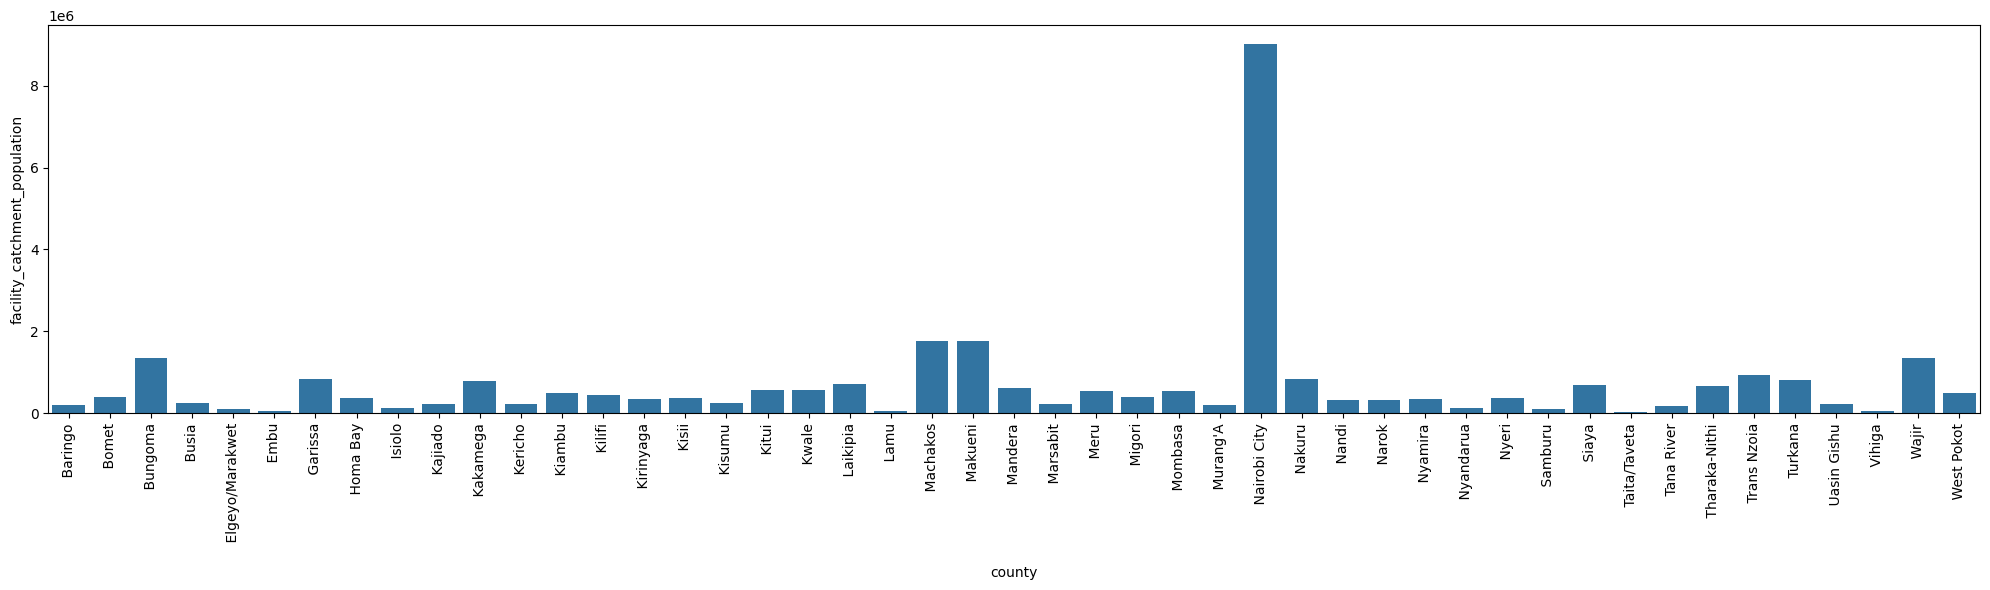

In [47]:
fig,axes=plt.subplots(figsize=(20,6))
sns.barplot(x='county', y='facility_catchment_population', data=Final_data)
plt.xticks(rotation=90)  # or rotation=90 for vertical labels
plt.tight_layout()
plt.show()

In [48]:
access_index =( Final_data['number_of_maternity_beds']/Final_data['female']) *( Final_data['no._of_facilities'] /Final_data['pop_total'])

In [49]:
access_index

0     3.535812e-09
1     1.414450e-08
2     1.889123e-08
3     6.954629e-09
4     1.622503e-08
5     7.018019e-11
6     1.119103e-08
7     1.442441e-08
8     5.410397e-08
9     4.231168e-09
10    8.740227e-09
11    3.850422e-09
12    2.427299e-09
13    2.697582e-09
14    4.469489e-08
15    1.283670e-09
16    3.085366e-09
17    3.453686e-08
18    5.876854e-09
19    9.154515e-09
20    3.114867e-08
21    1.003891e-08
22    1.136086e-07
23    3.867495e-08
24    6.196295e-08
25    1.461672e-08
26    1.826569e-08
27    7.265041e-10
28    2.959992e-09
29    2.372895e-09
30    1.929629e-08
31    2.524156e-08
32    1.595386e-08
33    2.022586e-08
34    4.284503e-09
35    3.679485e-09
36    3.609694e-09
37    6.154756e-08
38    6.525920e-09
39    0.000000e+00
40    7.304674e-08
41    3.047758e-08
42    5.364226e-08
43    5.943880e-10
44    4.647700e-10
45    3.771641e-08
46    1.118329e-07
dtype: float64

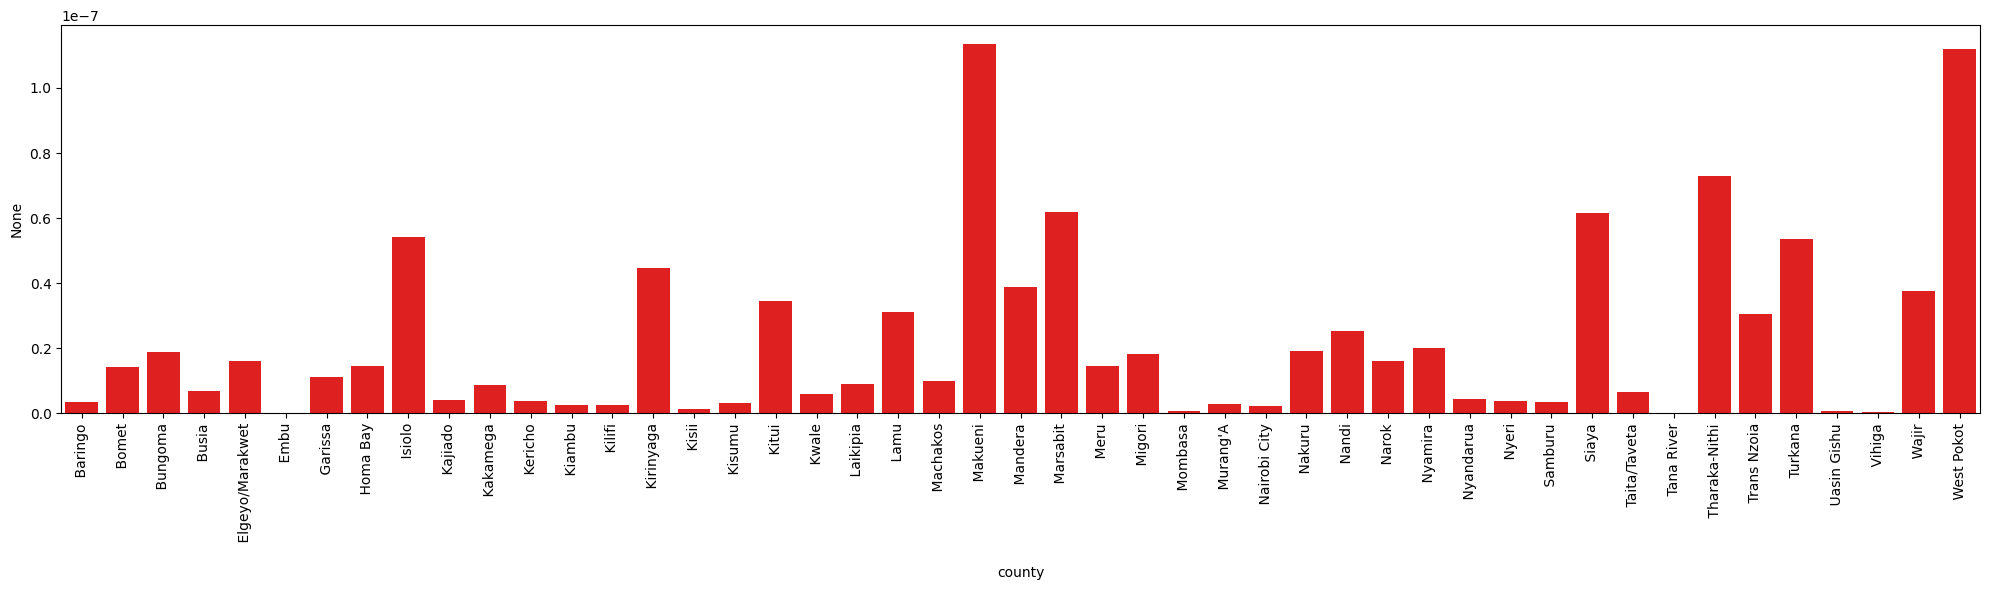

In [50]:
fig,axes=plt.subplots(figsize=(20,6))
sns.barplot(x='county', y=access_index, data=Final_data, color='red')
plt.xticks(rotation=90)  # or rotation=90 for vertical labels
plt.tight_layout()
plt.show()

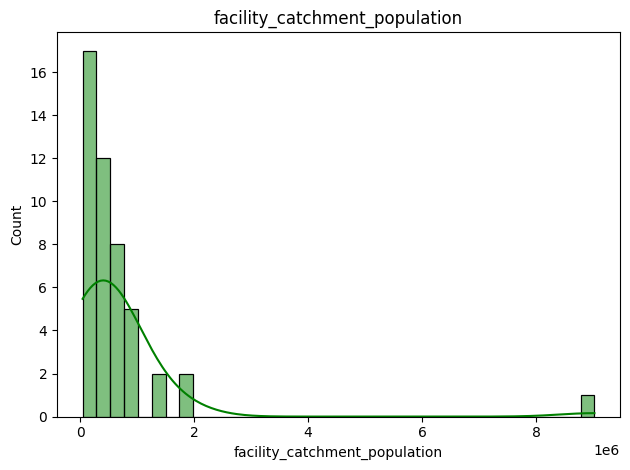

In [51]:
sns.histplot(data=Final_data, x='facility_catchment_population', kde=True, color='green')
plt.title('facility_catchment_population')
plt.tight_layout()
plt.show()

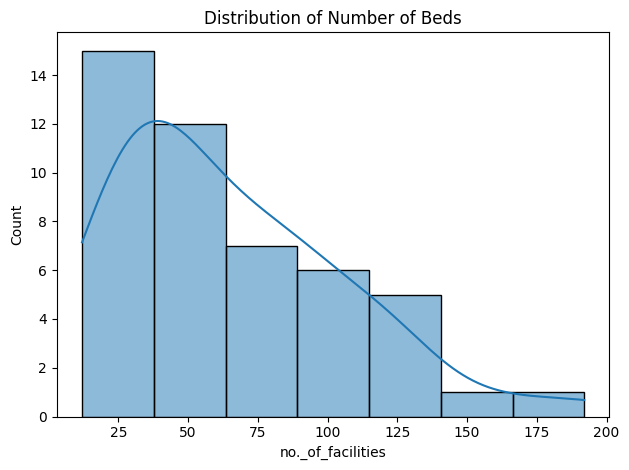

In [52]:
sns.histplot(data=Final_data, x='no._of_facilities', kde=True)
plt.title('Distribution of Number of Beds')
plt.tight_layout()
plt.show()

In [53]:
#Save the figure
fig.savefig("C:/Users/HomePC/Desktop/CSA2025/Group1-Healthcare_Access_Inequality_Predictor/Data/Output/histplot.png")

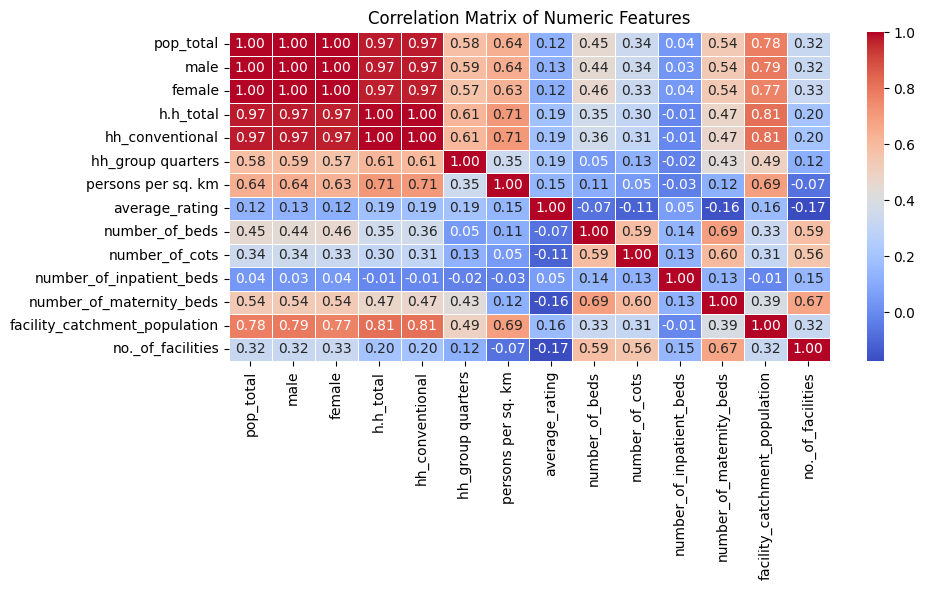

In [54]:
# Create a correlation matrix for the numerical values
num_variables = Final_data.select_dtypes(include='number')

# Create a correlation matrix
corr_matrix = num_variables.corr()

# Make a heatmap out of the corr_matrix
plt.figure(figsize=(10, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Matrix of Numeric Features')
plt.tight_layout()
plt.show()

C:\Users\HomePC\AppData\Local\Temp\ipykernel_31436\2329202100.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='beds_per_1k', y='county', data=lowest_beds, ax=axes[0], palette="Reds_r")
C:\Users\HomePC\AppData\Local\Temp\ipykernel_31436\2329202100.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='facilities_per_100k', y='county', data=lowest_facilities, ax=axes[1], palette="Blues_r")


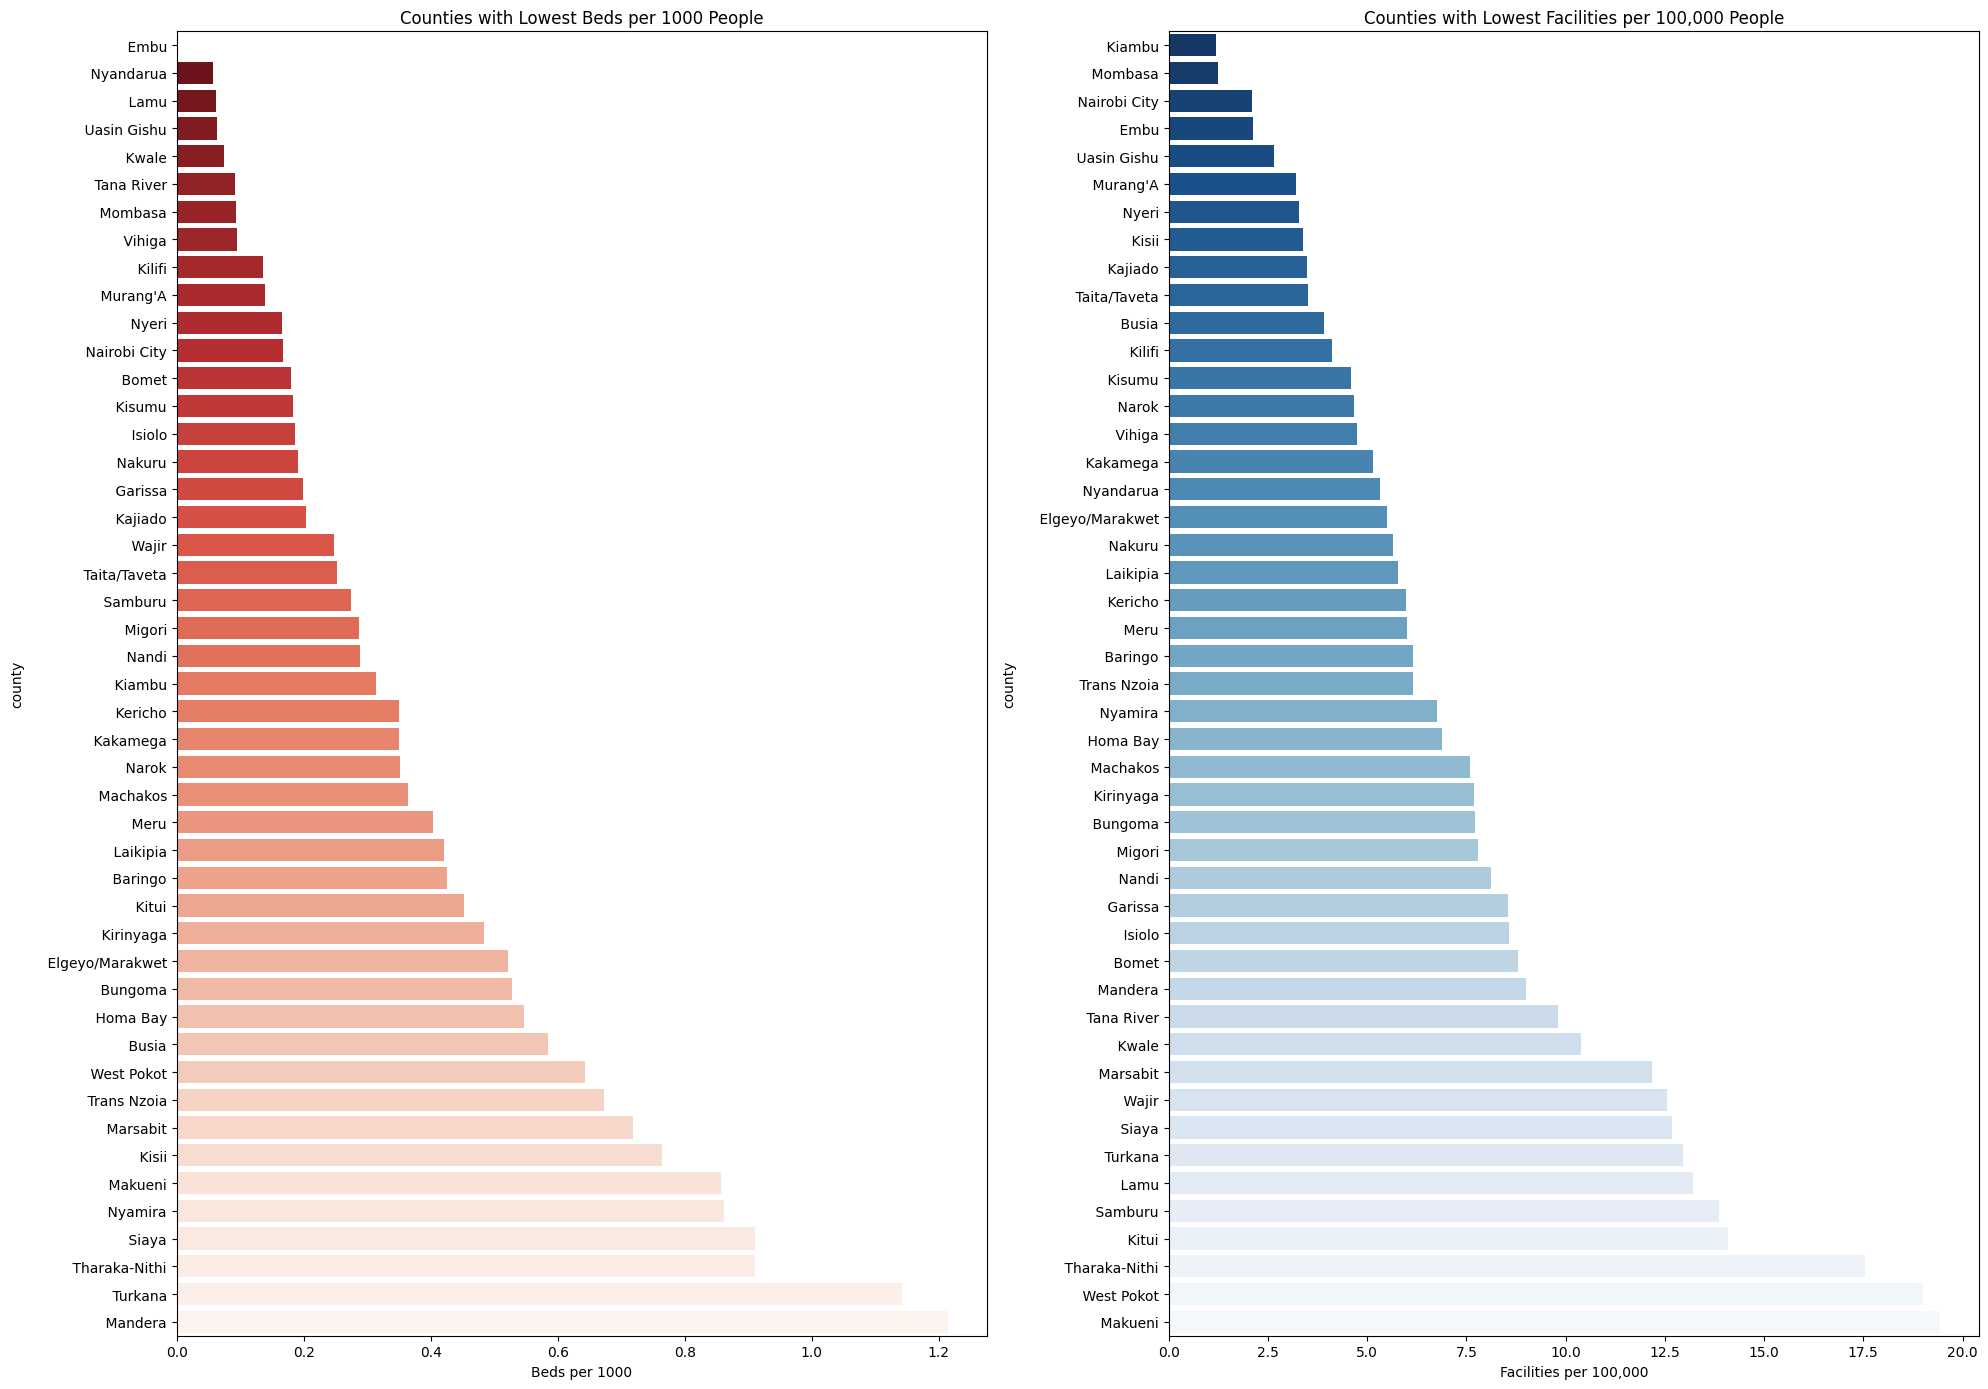

In [74]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load your cleaned dataframe (if not already in memory)
#df = pd.read_csv("final_data.csv")

# Clean the necessary numeric columns (remove commas)
columns_to_clean = [
    'pop_total', 'male', 'female', 'h.h_total',
    'hh_conventional', 'hh_group quarters', 'persons per sq. km'
]
for col in columns_to_clean:
    Final_data[col] = Final_data[col].astype(str).str.replace(',', '', regex=False)
    Final_data[col] = pd.to_numeric(Final_data[col], errors='coerce')

# Compute per capita metrics
Final_data['beds_per_1k'] = (Final_data['number_of_beds'] / Final_data['pop_total']) * 1000
Final_data['facilities_per_100k'] = (Final_data['no._of_facilities'] / Final_data['pop_total']) * 100000

# Sort and get bottom 5 counties
lowest_beds = Final_data[['county', 'beds_per_1k']].sort_values(by='beds_per_1k')#.head(5)
lowest_facilities = Final_data[['county', 'facilities_per_100k']].sort_values(by='facilities_per_100k')#.head(5)

# Plot
fig, axes = plt.subplots(1, 2, figsize=(20, 14))
sns.barplot(x='beds_per_1k', y='county', data=lowest_beds, ax=axes[0], palette="Reds_r")
axes[0].set_title('Counties with Lowest Beds per 1000 People')
axes[0].set_xlabel('Beds per 1000')

sns.barplot(x='facilities_per_100k', y='county', data=lowest_facilities, ax=axes[1], palette="Blues_r")
axes[1].set_title('Counties with Lowest Facilities per 100,000 People')
axes[1].set_xlabel('Facilities per 100,000')

plt.tight_layout()
plt.show()

# Counties like embu, Nyandarua, lamu, Uasin Gishu and kwale have extremely low availability of beds relative to their population while counties like Nairobi ,Mombasa, Embu has the lowest number of facilities per 100,000 people
 

In [79]:
county_population = Final_data


In [84]:
county_population.to_csv("county_population.csv", index=False)


In [82]:
# facility_beds= Final_Data 
# facility_beds.to

In [85]:
population = pd.read_csv("county_population.csv")

In [86]:
population.head()

,county,pop_total,male,female,h.h_total,hh_conventional,hh_group quarters,persons per sq. km,average_rating,number_of_beds,number_of_cots,number_of_inpatient_beds,number_of_maternity_beds,facility_catchment_population,no._of_facilities,beds_per_100k,facilities_per_100k,beds_per_1k
0,Baringo,666763,336322,330428,142518,141877,641,60.699676,0.003902,284,16,15,19,204309.0,41,0.425938,6.149111,0.425938
1,Bomet,875689,434287,441379,187641,187230,411,349.286947,0.012987,157,19,12,71,398032.0,77,0.179287,8.793076,0.179287
2,Bungoma,1670570,812146,858389,358796,357714,1082,552.448500,0.019748,881,67,295,210,1342280.0,129,0.527365,7.721915,0.527365
3,Busia,893681,426252,467401,198152,197944,208,525.761629,0.012500,523,1,219,83,243454.0,35,0.585220,3.916386,0.585220
4,Elgeyo/Marakwet,454480,227317,227151,99861,99119,742,149.891529,0.050000,237,23,2,67,108943.0,25,0.521475,5.500792,0.521475


In [91]:
population.drop(columns=["male","female","h.h_total","hh_conventional","hh_group quarters","persons per sq. km","average_rating","number_of_beds","number_of_cots","number_of_inpatient_beds","number_of_maternity_beds","facility_catchment_population","no._of_facilities","beds_per_100k","facilities_per_100k","beds_per_1k"],inplace=True)

In [92]:
population.head()

,county,pop_total
0,Baringo,666763
1,Bomet,875689
2,Bungoma,1670570
3,Busia,893681
4,Elgeyo/Marakwet,454480


In [99]:
summary = Final_data.groupby('county')[["number_of_beds","number_of_cots","number_of_inpatient_beds","number_of_maternity_beds","facility_catchment_population","no._of_facilities","beds_per_1k"]].sum().reset_index()

In [96]:
health_data.head()

,Unnamed: 0,facility_type_name,owner_name,owner_type_name,admission_status_name,county,constituency,ward_name,average_rating,facility_services,...,number_of_maternity_beds,number_of_isolation_beds,number_of_general_theatres,number_of_maternity_theatres,number_of_minor_theatres,number_of_eye_theatres,new_born_unit,facility_catchment_population,Latitude,Longitude
0,2,Dispensary,Ministry of Health,Ministry of Health,Admitting Maternity Patients Only,Trans Nzoia,Endebess,Endebess,0.0,[],...,2,0,0,0,0,0,False,5000.0,[1.02393,34.77484]
1,3,Dispensary,Ministry of Health,Ministry of Health,Admitting Maternity Patients Only,Trans Nzoia,Endebess,Chepchoina,0.0,"[{'average_rating': 0, 'category_id': '281fa08...",...,0,0,0,0,0,0,False,6000.0,[1.1351849999999999,34.806785]
2,4,Dispensary,Ministry of Health,Ministry of Health,Admitting Maternity Patients Only,Trans Nzoia,Endebess,Matumbei,0.0,[],...,3,0,0,0,0,0,False,10426.0,[1.08089,34.80747]
3,5,Dispensary,Ministry of Health,Ministry of Health,Admitting Maternity Patients Only,Trans Nzoia,Endebess,Endebess,0.0,"[{'average_rating': 0, 'category_id': '281fa08...",...,3,0,0,0,0,0,False,4579.0,[1.037451,34.861203]
4,6,Dispensary,Ministry of Health,Ministry of Health,Admitting Maternity Patients Only,Trans Nzoia,Endebess,Chepchoina,0.0,"[{'average_rating': 0, 'category_id': '281fa08...",...,3,0,0,0,0,0,False,6459.0,[1.2035879999999999,34.803397]


In [100]:
summary.head()

,county,number_of_beds,number_of_cots,number_of_inpatient_beds,number_of_maternity_beds,facility_catchment_population,no._of_facilities,beds_per_1k
0,Baringo,284,16,15,19,204309.0,41,0.425938
1,Bomet,157,19,12,71,398032.0,77,0.179287
2,Bungoma,881,67,295,210,1342280.0,129,0.527365
3,Busia,523,1,219,83,243454.0,35,0.585220
4,Elgeyo/Marakwet,237,23,2,67,108943.0,25,0.521475


In [123]:
 hospital_resources = summary 

In [124]:
hospital_resources.head()

,county,number_of_beds,number_of_cots,number_of_inpatient_beds,number_of_maternity_beds,facility_catchment_population,no._of_facilities,beds_per_1k
0,Baringo,284,16,15,19,204309.0,41,0.425938
1,Bomet,157,19,12,71,398032.0,77,0.179287
2,Bungoma,881,67,295,210,1342280.0,129,0.527365
3,Busia,523,1,219,83,243454.0,35,0.585220
4,Elgeyo/Marakwet,237,23,2,67,108943.0,25,0.521475


In [119]:
hospital_resources.to_csv("hospital_resources.csv", index=False)

In [113]:
!pip install geopandas

<Axes: >

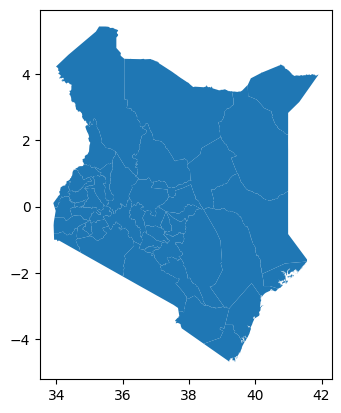

In [114]:
import geopandas as gpd

counties = gpd.read_file('C:/Users/HomePC/Downloads/kenyan-counties')
counties.plot()

In [115]:
counties['centroid'] = counties.geometry.centroid
counties['Latitude'] = counties.centroid.y
counties['Longitude'] = counties.centroid.x

C:\Users\HomePC\AppData\Local\Temp\ipykernel_31436\2750178980.py:1: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  counties['centroid'] = counties.geometry.centroid
C:\Users\HomePC\AppData\Local\Temp\ipykernel_31436\2750178980.py:2: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  counties['Latitude'] = counties.centroid.y
C:\Users\HomePC\AppData\Local\Temp\ipykernel_31436\2750178980.py:3: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  counties['Longitude'] = counties.centroid.x


In [116]:


# Reproject to a projected CRS (e.g. UTM Zone 37N for Kenya)
counties_proj = counties.to_crs(epsg=32637)  # UTM Zone 37N

# Now calculate centroids
counties_proj['centroid'] = counties_proj.geometry.centroid

# Convert back to geographic CRS for mapping
centroids_geo = counties_proj.copy()
centroids_geo = centroids_geo.to_crs(epsg=4326)

# Extract Lat/Lon
centroids_geo['Latitude'] = centroids_geo['centroid'].y
centroids_geo['Longitude'] = centroids_geo['centroid'].x


In [117]:
centroids_geo.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 47 entries, 0 to 46
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   OBJECTID    47 non-null     int32   
 1   AREA        47 non-null     float64 
 2   PERIMETER   47 non-null     float64 
 3   COUNTY3_    47 non-null     float64 
 4   COUNTY3_ID  47 non-null     float64 
 5   COUNTY      47 non-null     object  
 6   Shape_Leng  47 non-null     float64 
 7   Shape_Area  47 non-null     float64 
 8   geometry    47 non-null     geometry
 9   centroid    47 non-null     geometry
 10  Latitude    47 non-null     float64 
 11  Longitude   47 non-null     float64 
dtypes: float64(8), geometry(2), int32(1), object(1)
memory usage: 4.4+ KB


In [132]:
print(counties.columns)

Index(['OBJECTID', 'AREA', 'PERIMETER', 'COUNTY3_', 'COUNTY3_ID', 'county',
       'Shape_Leng', 'Shape_Area', 'geometry', 'centroid', 'Latitude',
       'Longitude'],
      dtype='object')


In [131]:
counties = counties.rename(columns={'COUNTY': 'county'})

In [174]:
counties

,OBJECTID,AREA,PERIMETER,COUNTY3_,COUNTY3_ID,county,Shape_Leng,Shape_Area,geometry,centroid,Latitude,Longitude
0,1,5.677,15.047,2.0,1.0,Turkana,15.046838,5.676985,"POLYGON ((35.79593 5.34449, 35.79659 5.34468, ...",POINT (35.43496 3.41296),3.412964,35.434957
1,2,6.177,11.974,3.0,2.0,Marsabit,11.974165,6.176831,"POLYGON ((36.05061 4.45622, 36.23184 4.45124, ...",POINT (37.56799 2.9805),2.980503,37.567986
2,3,2.117,7.355,4.0,3.0,Mandera,7.355154,2.117196,"POLYGON ((41.62133 3.97673, 41.62272 3.9786, 4...",POINT (40.73665 3.4384),3.438400,40.736653
3,4,4.610,9.838,5.0,4.0,Wajir,9.838408,4.609589,"POLYGON ((39.31812 3.47197, 39.31956 3.47168, ...",POINT (40.03356 1.80971),1.809709,40.033556
4,5,0.740,5.030,6.0,5.0,West Pokot,5.030271,0.740481,"POLYGON ((35.12745 2.62271, 35.12762 2.62302, ...",POINT (35.2431 1.72734),1.727335,35.243096
5,6,1.713,8.311,7.0,6.0,Samburu,8.311013,1.713014,"POLYGON ((36.73652 2.51379, 36.73706 2.51398, ...",POINT (37.1168 1.31988),1.319877,37.116796
6,7,2.060,10.181,8.0,7.0,Isiolo,10.181411,2.059820,"POLYGON ((37.94529 1.26288, 38.33966 1.57742, ...",POINT (38.5391 1.01183),1.011826,38.539096
7,8,0.877,5.964,9.0,8.0,Baringo,5.964266,0.877177,"POLYGON ((35.70707 1.4216, 35.70693 1.42253, 3...",POINT (35.94033 0.67643),0.676434,35.940325
8,9,0.245,4.064,10.0,9.0,Keiyo-Marakwet,4.063527,0.245208,"POLYGON ((35.7028 1.24649, 35.70271 1.24591, 3...",POINT (35.5364 0.79964),0.799635,35.536404
9,10,0.202,2.387,11.0,10.0,Trans Nzoia,2.387265,0.201983,"POLYGON ((34.82016 1.25983, 34.82024 1.26042, ...",POINT (34.95709 1.05183),1.051829,34.957093


In [142]:
census_sorted = counties.sort_values(by='county')

In [143]:
census_sorted.head()

,OBJECTID,AREA,PERIMETER,COUNTY3_,COUNTY3_ID,county,Shape_Leng,Shape_Area,geometry,centroid,Latitude,Longitude
7,8,0.877,5.964,9.0,8.0,Baringo,5.964266,0.877177,"POLYGON ((35.70707 1.4216, 35.70693 1.42253, 3...",POINT (35.94033 0.67643),0.676434,35.940325
31,32,0.229,2.632,33.0,32.0,Bomet,2.631657,0.229037,"POLYGON ((35.32763 -0.40701, 35.32771 -0.40674...",POINT (35.28131 -0.69152),-0.691519,35.281313
10,11,0.246,3.076,12.0,11.0,Bungoma,3.075944,0.245741,"POLYGON ((34.58077 1.15033, 34.61261 1.10971, ...",POINT (34.63918 0.75136),0.751363,34.639184
15,16,0.148,2.683,17.0,16.0,Busia,2.682712,0.147514,"POLYGON ((34.43332 0.7357, 34.43318 0.7352, 34...",POINT (34.19384 0.38992),0.389917,34.193840
29,30,0.230,3.339,31.0,30.0,Embu,3.339148,0.229668,"POLYGON ((37.92902 -0.42571, 37.92938 -0.42533...",POINT (37.62519 -0.6013),-0.601301,37.625190


In [149]:
census_sorted.reset_index(inplace=True)

In [153]:
census_sorted.head()

,OBJECTID,AREA,PERIMETER,COUNTY3_,COUNTY3_ID,county,Shape_Leng,Shape_Area,geometry,centroid,Latitude,Longitude
0,8,0.877,5.964,9.0,8.0,Baringo,5.964266,0.877177,"POLYGON ((35.70707 1.4216, 35.70693 1.42253, 3...",POINT (35.94033 0.67643),0.676434,35.940325
1,32,0.229,2.632,33.0,32.0,Bomet,2.631657,0.229037,"POLYGON ((35.32763 -0.40701, 35.32771 -0.40674...",POINT (35.28131 -0.69152),-0.691519,35.281313
2,11,0.246,3.076,12.0,11.0,Bungoma,3.075944,0.245741,"POLYGON ((34.58077 1.15033, 34.61261 1.10971, ...",POINT (34.63918 0.75136),0.751363,34.639184
3,16,0.148,2.683,17.0,16.0,Busia,2.682712,0.147514,"POLYGON ((34.43332 0.7357, 34.43318 0.7352, 34...",POINT (34.19384 0.38992),0.389917,34.193840
4,30,0.230,3.339,31.0,30.0,Embu,3.339148,0.229668,"POLYGON ((37.92902 -0.42571, 37.92938 -0.42533...",POINT (37.62519 -0.6013),-0.601301,37.625190


In [175]:
census_sorted.drop(columns =['index'],inplace=True)

KeyError: "['index'] not found in axis"

In [ ]:
# Step 1: Reproject to projected CRS (UTM Zone 37N for Kenya)
counties_proj = counties.to_crs(epsg=32637)

# Step 2: Calculate centroids
counties_proj['centroid'] = counties_proj.geometry.centroid

# Step 3: Convert back to EPSG:4326 for lat/lon usage
counties_proj = counties_proj.to_crs(epsg=4326)

# Step 4: Extract lat/lon from centroid column
counties_proj['Latitude'] = counties_proj['centroid'].apply(lambda point: point.y)
counties_proj['Longitude'] = counties_proj['centroid'].apply(lambda point: point.x)

# # Step 5: Standardize county name column
# counties_proj = counties_proj.rename(columns={'COUNTY_NAM': 'county'})  # Adjust if needed

# Step 6: Merge with hospital data
hospital_data = pd.read_csv('hospital_resources.csv')
geo_df = pd.concat([hospital_data,census_sorted],axis=1)


In [176]:
geo_df.head()

,county,number_of_beds,number_of_cots,number_of_inpatient_beds,number_of_maternity_beds,...,Shape_Area,geometry,centroid,Latitude,Longitude
0,Baringo,284,16,15,19,...,0.877177,"POLYGON ((35.70707 1.4216, 35.70693 1.42253, 3...",POINT (35.94033 0.67643),0.676434,35.940325
1,Bomet,157,19,12,71,...,0.229037,"POLYGON ((35.32763 -0.40701, 35.32771 -0.40674...",POINT (35.28131 -0.69152),-0.691519,35.281313
2,Bungoma,881,67,295,210,...,0.245741,"POLYGON ((34.58077 1.15033, 34.61261 1.10971, ...",POINT (34.63918 0.75136),0.751363,34.639184
3,Busia,523,1,219,83,...,0.147514,"POLYGON ((34.43332 0.7357, 34.43318 0.7352, 34...",POINT (34.19384 0.38992),0.389917,34.193840
4,Elgeyo/Marakwet,237,23,2,67,...,0.229668,"POLYGON ((37.92902 -0.42571, 37.92938 -0.42533...",POINT (37.62519 -0.6013),-0.601301,37.625190


In [177]:
geo_df = geo_df.loc[:, ~geo_df.columns.duplicated()]

In [178]:
geo_df.head()

,county,number_of_beds,number_of_cots,number_of_inpatient_beds,number_of_maternity_beds,...,Shape_Area,geometry,centroid,Latitude,Longitude
0,Baringo,284,16,15,19,...,0.877177,"POLYGON ((35.70707 1.4216, 35.70693 1.42253, 3...",POINT (35.94033 0.67643),0.676434,35.940325
1,Bomet,157,19,12,71,...,0.229037,"POLYGON ((35.32763 -0.40701, 35.32771 -0.40674...",POINT (35.28131 -0.69152),-0.691519,35.281313
2,Bungoma,881,67,295,210,...,0.245741,"POLYGON ((34.58077 1.15033, 34.61261 1.10971, ...",POINT (34.63918 0.75136),0.751363,34.639184
3,Busia,523,1,219,83,...,0.147514,"POLYGON ((34.43332 0.7357, 34.43318 0.7352, 34...",POINT (34.19384 0.38992),0.389917,34.193840
4,Elgeyo/Marakwet,237,23,2,67,...,0.229668,"POLYGON ((37.92902 -0.42571, 37.92938 -0.42533...",POINT (37.62519 -0.6013),-0.601301,37.625190


In [179]:
merged = pd.merge(population, geo_df, on='county')

In [180]:
merged.head()

,county,pop_total,number_of_beds,number_of_cots,number_of_inpatient_beds,number_of_maternity_beds,facility_catchment_population,no._of_facilities,beds_per_1k,OBJECTID,AREA,PERIMETER,COUNTY3_,COUNTY3_ID,Shape_Leng,Shape_Area,geometry,centroid,Latitude,Longitude
0,Baringo,666763,284,16,15,19,204309.0,41,0.425938,8,0.877,5.964,9.0,8.0,5.964266,0.877177,"POLYGON ((35.70707 1.4216, 35.70693 1.42253, 3...",POINT (35.94033 0.67643),0.676434,35.940325
1,Bomet,875689,157,19,12,71,398032.0,77,0.179287,32,0.229,2.632,33.0,32.0,2.631657,0.229037,"POLYGON ((35.32763 -0.40701, 35.32771 -0.40674...",POINT (35.28131 -0.69152),-0.691519,35.281313
2,Bungoma,1670570,881,67,295,210,1342280.0,129,0.527365,11,0.246,3.076,12.0,11.0,3.075944,0.245741,"POLYGON ((34.58077 1.15033, 34.61261 1.10971, ...",POINT (34.63918 0.75136),0.751363,34.639184
3,Busia,893681,523,1,219,83,243454.0,35,0.585220,16,0.148,2.683,17.0,16.0,2.682712,0.147514,"POLYGON ((34.43332 0.7357, 34.43318 0.7352, 34...",POINT (34.19384 0.38992),0.389917,34.193840
4,Elgeyo/Marakwet,454480,237,23,2,67,108943.0,25,0.521475,30,0.230,3.339,31.0,30.0,3.339148,0.229668,"POLYGON ((37.92902 -0.42571, 37.92938 -0.42533...",POINT (37.62519 -0.6013),-0.601301,37.625190


In [161]:
!pip install geojson

In [181]:
import geojson

features = []
for _, row in merged.iterrows():
    point = geojson.Point((row['Longitude'], row['Latitude']))
    props = {
        "county": row['county'],
        "pop_total": row['pop_total'],
        "number_of_beds	": row['number_of_beds'],
        "number_of_cots": row['number_of_cots'],
        "number_of_inpatient_beds":row['number_of_inpatient_beds'],
        "number_of_maternity_beds": row['number_of_maternity_beds'],
        "no._of_facilities":row['no._of_facilities'],
        "beds_per_1k": round(row['beds_per_1k'], 2)
    }
    features.append(geojson.Feature(geometry=point, properties=props))

geo_data = geojson.FeatureCollection(features)

with open("kenya_county_hospital_summary.geojson", "w") as f:
    geojson.dump(geo_data, f)



In [165]:
!pip install folium


   -------------------------- ------------- 2/3 [folium]
   ---------------------------------------- 3/3 [folium]



In [182]:
import folium
import geojson

# Load the GeoJSON file
with open("kenya_county_hospital_summary.geojson") as f:
    geo_data = geojson.load(f)

# Set up base map (centered on Kenya)
m = folium.Map(location=[0.0236, 37.9062], zoom_start=6)

# Add GeoJSON layer
folium.GeoJson(
    geo_data,
    name="Healthcare Access",
    tooltip=folium.GeoJsonTooltip(fields=["county", "pop_total", "beds_per_1k","no._of_facilities"])
).add_to(m)

# Show the map
m.save("county_healthcare_map.html")

In [169]:
import streamlit as st
import streamlit.components.v1 as components

with open("county_healthcare_map.html", 'r') as f:
    map_html = f.read()

components.html(map_html, height=600)


2025-08-03 14:28:07.541 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-08-03 14:28:08.635 
  command:

    streamlit run C:\Users\HomePC\anaconda3\envs\HS_access_env\Lib\site-packages\ipykernel_launcher.py [ARGUMENTS]
2025-08-03 14:28:08.636 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-08-03 14:28:08.636 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.


DeltaGenerator()

In [ ]:
import geopandas as gpd

# Load Kenya counties shapefile
kenya_gdf = gpd.read_file("kenya_counties.geojson")

# Merge with your GeoJSON data (converted to DataFrame)
hospital_df = pd.json_normalize(geo_data["features"])
hospital_df.rename(columns={"properties.county": "county"}, inplace=True)

# Merge and plot
merged_gdf = kenya_gdf.merge(hospital_df, on="county")
merged_gdf.plot(column="properties.Beds_per_1000", cmap="OrRd", legend=True)


In [183]:
folium.Map(location=[-0.0236, 37.9062], zoom_start=6).add_child(
    folium.GeoJson(data=geo_df)
)


ValueError: Cannot render objects with any missing geometries:                  county  number_of_beds  number_of_cots  \
0               Baringo             284              16   
1                 Bomet             157              19   
2               Bungoma             881              67   
3                 Busia             523               1   
4       Elgeyo/Marakwet             237              23   
5                  Embu               0               0   
6               Garissa             167              49   
7              Homa Bay             619              36   
8                Isiolo              50              72   
9               Kajiado             228              19   
10             Kakamega             655              41   
11              Kericho             316              31   
12               Kiambu             760              93   
13               Kilifi             198              18   
14            Kirinyaga             295             